## 0. Settings

In [33]:
pip install scikit-optimize

In [34]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import LeaveOneOut
from sklearn.dummy import DummyClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.neural_network import MLPClassifier
from sklearn import svm
from sklearn.ensemble import VotingClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from skopt import BayesSearchCV
from skopt.space import Real, Categorical, Integer
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score
import time



## 1. Data loading

In [35]:
#If you use a drive
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/Article sound/stats.csv', sep=",")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [36]:
#If you use work on github
#df = pd.read_csv('https://raw.githubusercontent.com/foguedjombou/stone-impact-sound-analysis/stats.csv')

## 2. Preprocessings

#### Data **shaping**

In [37]:
df.iloc[28, 2:4] = 0
df

,sample_name,form_1,frost_resitant_01,frost_resitant_001,f1_vibration,rms_1,rms_2,rms_3,rms_4,rms_5,...,centroid_min,centroid_max,c_mean,c_std,c_min,c_max,Q_mean,Q_std,Q_min,Q_max
0,S01,pl,1.0,0.0,2748.000000,0.122204,0.129421,0.111234,0.128124,0.130879,...,4881.061628,6893.026751,60.477033,3.449210,55.140871,66.255863,167.954184,9.431595,152.978751,183.579095
1,S02,pl,1.0,0.0,3289.000000,0.118736,0.145612,0.109484,0.137154,0.138425,...,5358.211364,8567.668763,53.673212,2.587895,48.540497,56.854063,203.424889,13.742620,184.304188,232.428568
2,S03,pl,1.0,0.0,1665.211513,0.105056,0.118863,0.093317,0.106551,0.100342,...,4558.928434,6197.090933,54.272403,6.250442,44.583643,62.897749,169.427114,55.924457,96.014480,238.094629
3,S04,pt,1.0,0.0,5750.000000,0.103743,0.107076,0.106194,NaN,NaN,...,7279.460418,9268.764887,101.376921,4.126432,96.625126,104.057411,178.316366,7.428758,173.526595,186.874045
4,S05,pt,1.0,0.0,5372.000000,0.106428,0.103779,0.109662,NaN,NaN,...,6278.363827,7666.635800,92.852775,5.320721,86.709230,95.976631,181.969898,10.784015,175.648565,194.421719
5,S06,pt,1.0,0.0,5804.000000,0.102041,0.102716,0.102248,NaN,NaN,...,6869.146299,7280.095180,105.931849,3.683444,103.432419,110.161899,172.314161,5.879748,165.566494,176.338517
6,S07,pt,1.0,0.0,5447.000000,0.117247,0.121782,NaN,NaN,NaN,...,7246.237426,8143.358876,68.112623,0.766591,67.570562,68.654684,251.345491,2.828831,249.345205,253.345776
7,S08,pt,1.0,1.0,3370.000000,0.150835,0.161233,0.144541,NaN,NaN,...,5078.519540,5792.681481,43.131979,0.602065,42.526667,43.730744,243.180504,3.395579,239.819696,246.609816
8,S09,pt,1.0,1.0,3622.000000,0.142040,0.136088,0.133269,NaN,NaN,...,5596.319438,5826.901464,55.077694,0.974967,53.960332,55.755492,206.540839,3.691400,203.986967,210.773233
9,S10,pt,1.0,0.0,3115.000000,0.139613,0.143177,0.131833,NaN,NaN,...,5823.560949,6066.656816,52.387126,3.142826,50.166816,55.983247,185.204407,10.771016,172.904606,192.951478


In [38]:
#table with only statistical data
X_sub = df.drop(['sample_name',
'form_1',
 'rms_1',
 'rms_2',
 'rms_3',
 'rms_4',
 'rms_5',
 'rms_6',
 'rms_7',
 'rms_8',
 'rms_9',
 'flatness_1',
 'flatness_2',
 'flatness_3',
 'flatness_4',
 'flatness_5',
 'flatness_6',
 'flatness_7',
 'flatness_8',
 'flatness_9',
 'rolloff_1',
 'rolloff_2',
 'rolloff_3',
 'rolloff_4',
 'rolloff_5',
 'rolloff_6',
 'rolloff_7',
 'rolloff_8',
 'rolloff_9',
 'contrast_1',
 'contrast_2',
 'contrast_3',
 'contrast_4',
 'contrast_5',
 'contrast_6',
 'contrast_7',
 'contrast_8',
 'contrast_9',
 'f1_audio_1',
 'f1_audio_2',
 'f1_audio_3',
 'f1_audio_4',
 'f1_audio_5',
 'f1_audio_6',
 'f1_audio_7',
 'f1_audio_8',
 'f1_audio_9',
 'c_1',
 'c_2',
 'c_3',
 'c_4',
 'c_5',
 'c_6',
 'c_7',
 'c_8',
 'c_9',
 'centroid_1',
 'centroid_2',
 'centroid_3',
 'centroid_4',
 'centroid_5',
 'centroid_6',
 'centroid_7',
 'centroid_8',
 'centroid_9',
 'Q_1',
 'Q_2',
 'Q_3',
 'Q_4',
 'Q_5',
 'Q_6',
 'Q_7',
 'Q_8',
 'Q_9',],axis=1)


In [41]:
X = X_sub.drop(['frost_resitant_01', 'frost_resitant_001'], axis=1)
y = df.frost_resitant_01

#### Missing data imputation

In [45]:
X = X.fillna(X.mean())
X_sub = X_sub.fillna(X_sub.mean())

#### Data normalisation

In [47]:
X = (X-X.min()) / (X.max()-X.min())
X_sub = (X_sub-X_sub.min()) / (X_sub.max()-X_sub.min())

## 3. Correlations

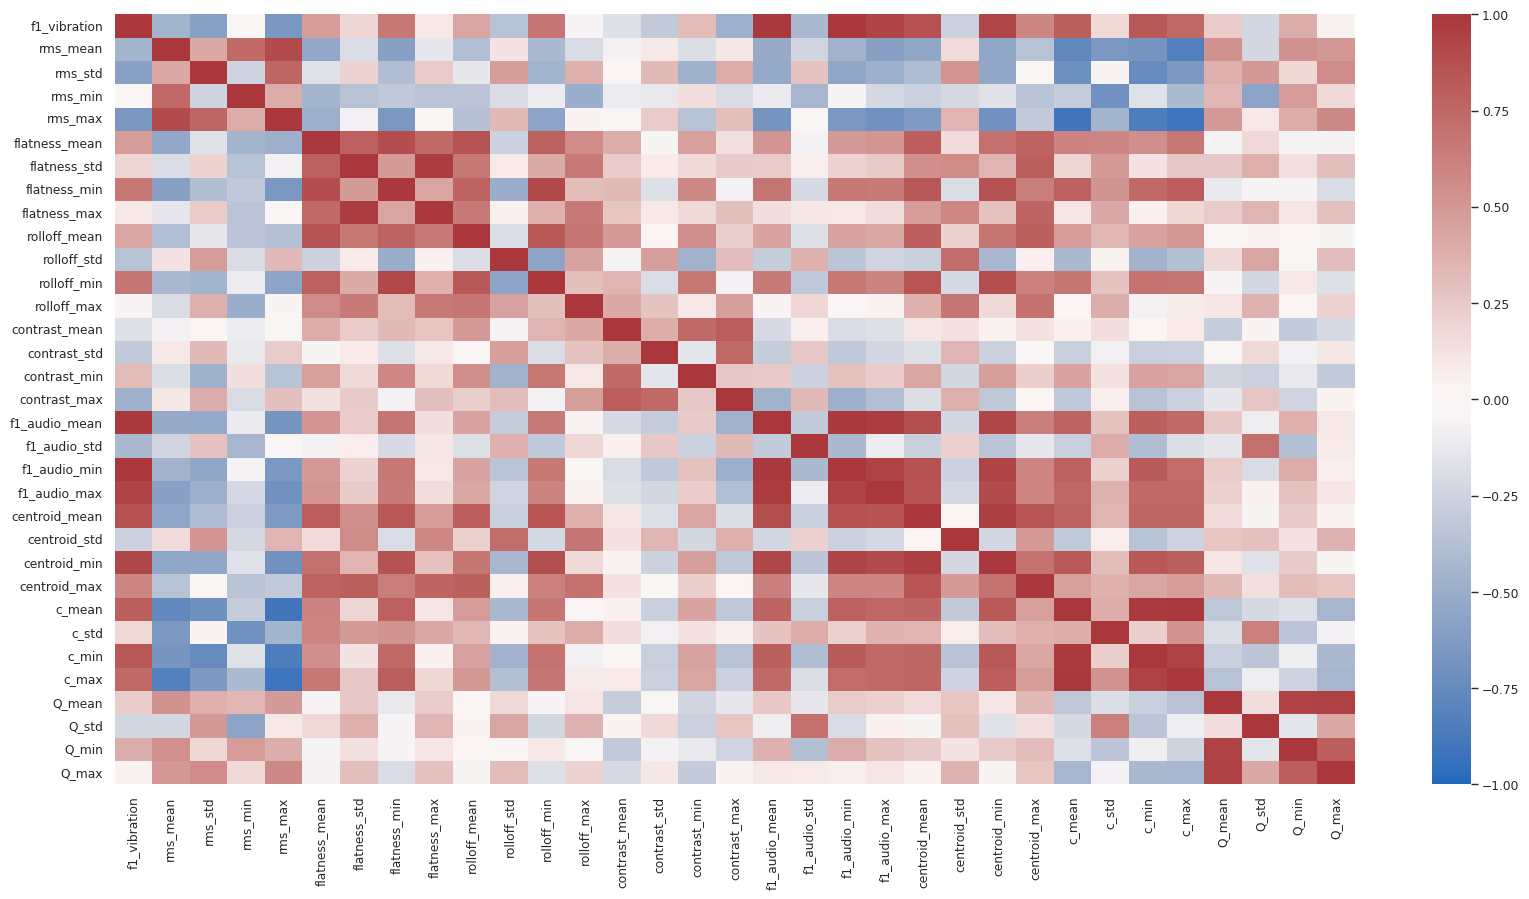

In [48]:
plt.figure(figsize=(20, 10))
heatmap = sns.heatmap(X.corr(), vmin=-1, vmax=1, cmap='vlag')
plt.show()

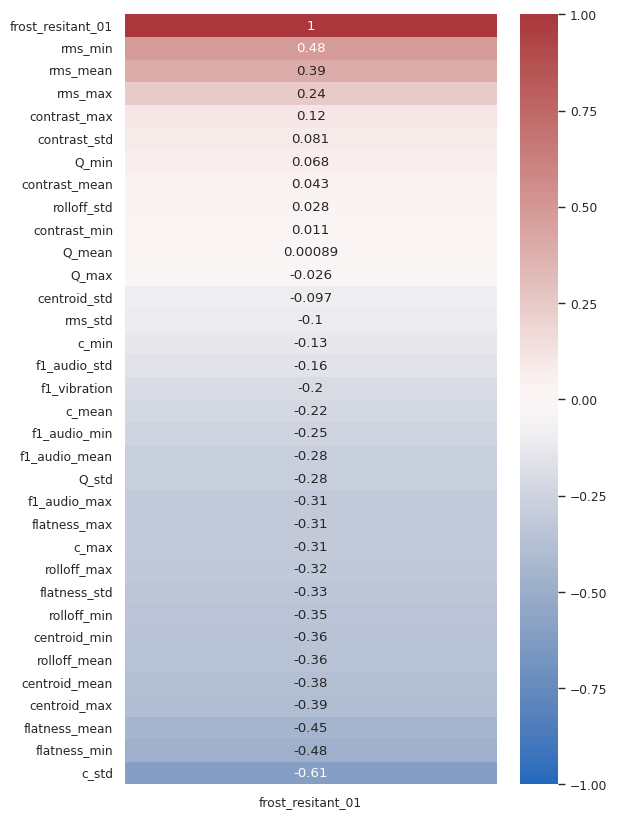

In [53]:
# Correlation according to X_sub01
X_sub01 = X_sub.drop(['frost_resitant_001',],axis=1)

corr = X_sub01.corr()

corr_target = corr["frost_resitant_01"].sort_values(ascending=False)

corr_target_df = corr[["frost_resitant_01"]].sort_values(by="frost_resitant_01", ascending=False)

plt.figure(figsize=(6, 10))
sns.heatmap(corr_target_df, annot=True, cmap="vlag", vmin=-1, vmax=1)
plt.show()

/tmp/ipykernel_2297/40717425.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


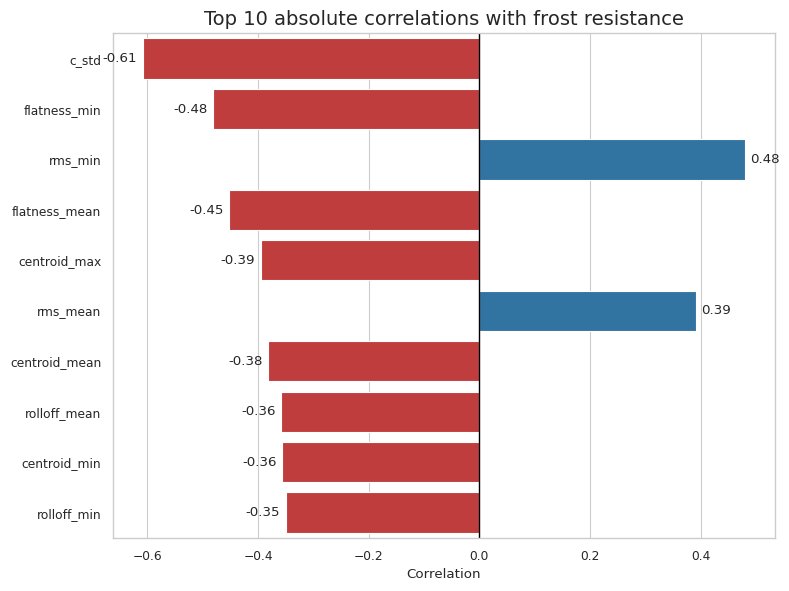

In [54]:
# Plotting of the best correlation

import seaborn as sns
import matplotlib.pyplot as plt

top10 = corr_target.drop("frost_resitant_01")
top10 = top10.reindex(top10.abs().sort_values(ascending=False).index).head(10)

df_plot = top10.reset_index()
df_plot.columns = ["Feature", "Correlation"]

sns.set(style="whitegrid")

sns.set_context("paper")

palette = ["#d62728" if val < 0 else "#1f77b4" for val in df_plot["Correlation"]]

plt.figure(figsize=(8, 6))
ax = sns.barplot(
    data=df_plot,
    x="Correlation",
    y="Feature",
    palette=palette
)

plt.axvline(0, color="black", linewidth=1)

for i, val in enumerate(df_plot["Correlation"]):
    ax.text(
        val + (0.01 if val > 0 else -0.01),
        i,
        f"{val:.2f}",
        va='center',
        ha='left' if val > 0 else 'right'
    )

# Titres
plt.title("Top 10 absolute correlations with frost resistance", fontsize=14)
plt.xlabel("Correlation")
plt.ylabel("")

plt.tight_layout()
plt.show()


## 4. Predictive assessment

#### Predictive pipeline

In [58]:
loo = LeaveOneOut()
dummy_preds = []; knn_preds = []; nb_preds = []; tree_preds = []; svm_preds = []; mlp_preds = []; vote_preds = []
stack_preds = []; forest_preds = []; adaboost_preds = []; gb_preds = []; xgb_preds = []
classif_models = ['dummy', 'tree', 'forest', 'adaboost', 'gb', 'xgb']
start_time = time.time()
for i, (train_index, test_index) in enumerate(loo.split(X)):

    X_train = X.iloc[train_index]
    X_test = X.iloc[test_index]
    y_train = y.iloc[train_index]
    y_test = y.iloc[test_index]

    # Models initialization
    dummy = DummyClassifier()
    tree = DecisionTreeClassifier()
    forest = RandomForestClassifier(n_jobs=-1)
    adaboost = AdaBoostClassifier()
    gb = GradientBoostingClassifier()
    xgb = XGBClassifier()

    # Training
    dummy.fit(X_train, y_train)
    tree.fit(X_train, y_train)
    forest.fit(X_train, y_train)
    adaboost.fit(X_train, y_train)
    gb.fit(X_train, y_train)
    xgb.fit(X_train, y_train)

    # Prediction
    dummy_preds.append(dummy.predict(X_test))
    tree_preds.append(tree.predict(X_test))
    forest_preds.append(forest.predict(X_test))
    adaboost_preds.append(adaboost.predict(X_test))
    gb_preds.append(gb.predict(X_test))
    xgb_preds.append(xgb.predict(X_test))

print("--- %s seconds ---" % (time.time() - start_time))

--- 27.93058729171753 seconds ---


#### Predictions evaluation

In [59]:
# Evaluation
acc_dummy = accuracy_score(y, dummy_preds)
acc_tree = accuracy_score(y, tree_preds)
acc_forest = accuracy_score(y, forest_preds)
acc_adaboost = accuracy_score(y, adaboost_preds)
acc_gb = accuracy_score(y, gb_preds)
acc_xgb = accuracy_score(y, xgb_preds)

pre_dummy = precision_score(y, dummy_preds)
pre_tree = precision_score(y, tree_preds)
pre_forest = precision_score(y, forest_preds)
pre_adaboost = precision_score(y, adaboost_preds)
pre_gb = precision_score(y, gb_preds)
pre_xgb = precision_score(y, xgb_preds)

rec_dummy = recall_score(y, dummy_preds)
rec_tree = recall_score(y, tree_preds)
rec_forest = recall_score(y, forest_preds)
rec_adaboost = recall_score(y, adaboost_preds)
rec_gb = recall_score(y, gb_preds)
rec_xgb = recall_score(y, xgb_preds)

auc_dummy = roc_auc_score(y, dummy_preds)
auc_tree = roc_auc_score(y, tree_preds)
auc_forest = roc_auc_score(y, forest_preds)
auc_adaboost = roc_auc_score(y, adaboost_preds)
auc_gb = roc_auc_score(y, gb_preds)
auc_xgb = roc_auc_score(y, xgb_preds)

#### Results shaping and printing

In [60]:
accuracies = pd.Series([acc_dummy, acc_tree, acc_forest, acc_adaboost, acc_gb, acc_xgb])
precisions = pd.Series([pre_dummy, pre_tree, pre_forest, pre_adaboost, pre_gb, pre_xgb])
recalls = pd.Series([rec_dummy, rec_tree, rec_forest, rec_adaboost, rec_gb, rec_xgb])
aucs = pd.Series([auc_dummy, auc_tree, auc_forest, auc_adaboost, auc_gb, auc_xgb])

accuracies.index = classif_models
precisions.index = classif_models
recalls.index = classif_models
aucs.index = classif_models

results = pd.concat([accuracies, precisions, recalls, aucs], axis=1)
results.columns = ['accuracy', 'precision', 'recall', 'AUC']
print(results)

          accuracy  precision    recall       AUC
dummy     0.709677   0.709677  1.000000  0.500000
tree      0.741935   0.850000  0.772727  0.719697
forest    0.709677   0.760000  0.863636  0.598485
adaboost  0.838710   0.869565  0.909091  0.787879
gb        0.806452   0.833333  0.909091  0.732323
xgb       0.774194   0.826087  0.863636  0.709596


5. Model interpretation

In [62]:
X.columns

Index(['f1_vibration', 'rms_mean', 'rms_std', 'rms_min', 'rms_max',
       'flatness_mean', 'flatness_std', 'flatness_min', 'flatness_max',
       'rolloff_mean', 'rolloff_std', 'rolloff_min', 'rolloff_max',
       'contrast_mean', 'contrast_std', 'contrast_min', 'contrast_max',
       'f1_audio_mean', 'f1_audio_std', 'f1_audio_min', 'f1_audio_max',
       'centroid_mean', 'centroid_std', 'centroid_min', 'centroid_max',
       'c_mean', 'c_std', 'c_min', 'c_max', 'Q_mean', 'Q_std', 'Q_min',
       'Q_max'],
      dtype='object')

In [63]:
X_sub

,frost_resitant_01,frost_resitant_001,f1_vibration,rms_mean,rms_std,rms_min,rms_max,flatness_mean,flatness_std,flatness_min,...,centroid_min,centroid_max,c_mean,c_std,c_min,c_max,Q_mean,Q_std,Q_min,Q_max
0,1.0,0.0,0.155636,0.367030,0.391818,0.427670,0.351265,0.159704,0.092117,0.065429,...,0.079117,0.214450,0.381416,0.174187,0.386066,0.388625,0.155409,0.145466,0.185678,0.150295
1,1.0,0.0,0.224848,0.519992,0.514429,0.537622,0.506357,0.225436,0.172912,0.180324,...,0.162453,0.540827,0.307101,0.124838,0.307354,0.295763,0.271742,0.224702,0.287785,0.292199
2,1.0,0.0,0.017110,0.144117,0.357827,0.222983,0.240994,0.122532,0.084690,0.060203,...,0.022855,0.078817,0.313646,0.334684,0.260167,0.355457,0.160240,1.000000,0.000000,0.308658
3,1.0,0.0,0.539694,0.211875,0.050260,0.463065,0.132819,0.411860,0.344792,0.309409,...,0.498008,0.677466,0.828145,0.212989,0.880782,0.761991,0.189394,0.108654,0.252655,0.159867
4,1.0,0.0,0.491334,0.223742,0.094634,0.463538,0.156553,0.156135,0.100008,0.157009,...,0.323162,0.365222,0.735040,0.281415,0.762531,0.682177,0.201376,0.170324,0.259572,0.181792
5,1.0,0.0,0.546602,0.170290,0.000000,0.440675,0.092808,0.157287,0.030328,0.252947,...,0.426345,0.289887,0.877896,0.187608,0.961962,0.822285,0.169708,0.080184,0.226709,0.129262
6,1.0,0.0,0.500930,0.384452,0.104095,0.640789,0.267780,0.181575,0.094152,0.245288,...,0.492206,0.458132,0.464815,0.020486,0.534295,0.412318,0.428907,0.024108,0.499790,0.352961
7,1.0,1.0,0.235211,0.791965,0.294142,1.000000,0.629843,0.016290,0.024338,0.072924,...,0.113604,0.000000,0.191964,0.011060,0.235636,0.166144,0.402128,0.034525,0.468741,0.333394
8,1.0,1.0,0.267450,0.604087,0.150348,0.851653,0.453700,0.062152,0.000000,0.156204,...,0.204040,0.006669,0.322442,0.032425,0.371987,0.284913,0.281961,0.039962,0.351942,0.229292
9,1.0,0.0,0.202587,0.617491,0.198491,0.832756,0.464135,0.105558,0.003524,0.214051,...,0.243729,0.053396,0.293054,0.156633,0.326748,0.287162,0.211984,0.170085,0.250628,0.177521


    importance        feature
10    0.258887          c_std
6     0.246091   contrast_std
3     0.095334   rolloff_mean
12    0.085343          Q_std
4     0.051158    rolloff_max
5     0.043945  contrast_mean
0     0.038693       rms_mean
1     0.038404        rms_std
13    0.037652          Q_max
2     0.023390   flatness_min
8     0.021136   f1_audio_min
7     0.021103   f1_audio_std
9     0.019582   f1_audio_max
11    0.019282         Q_mean


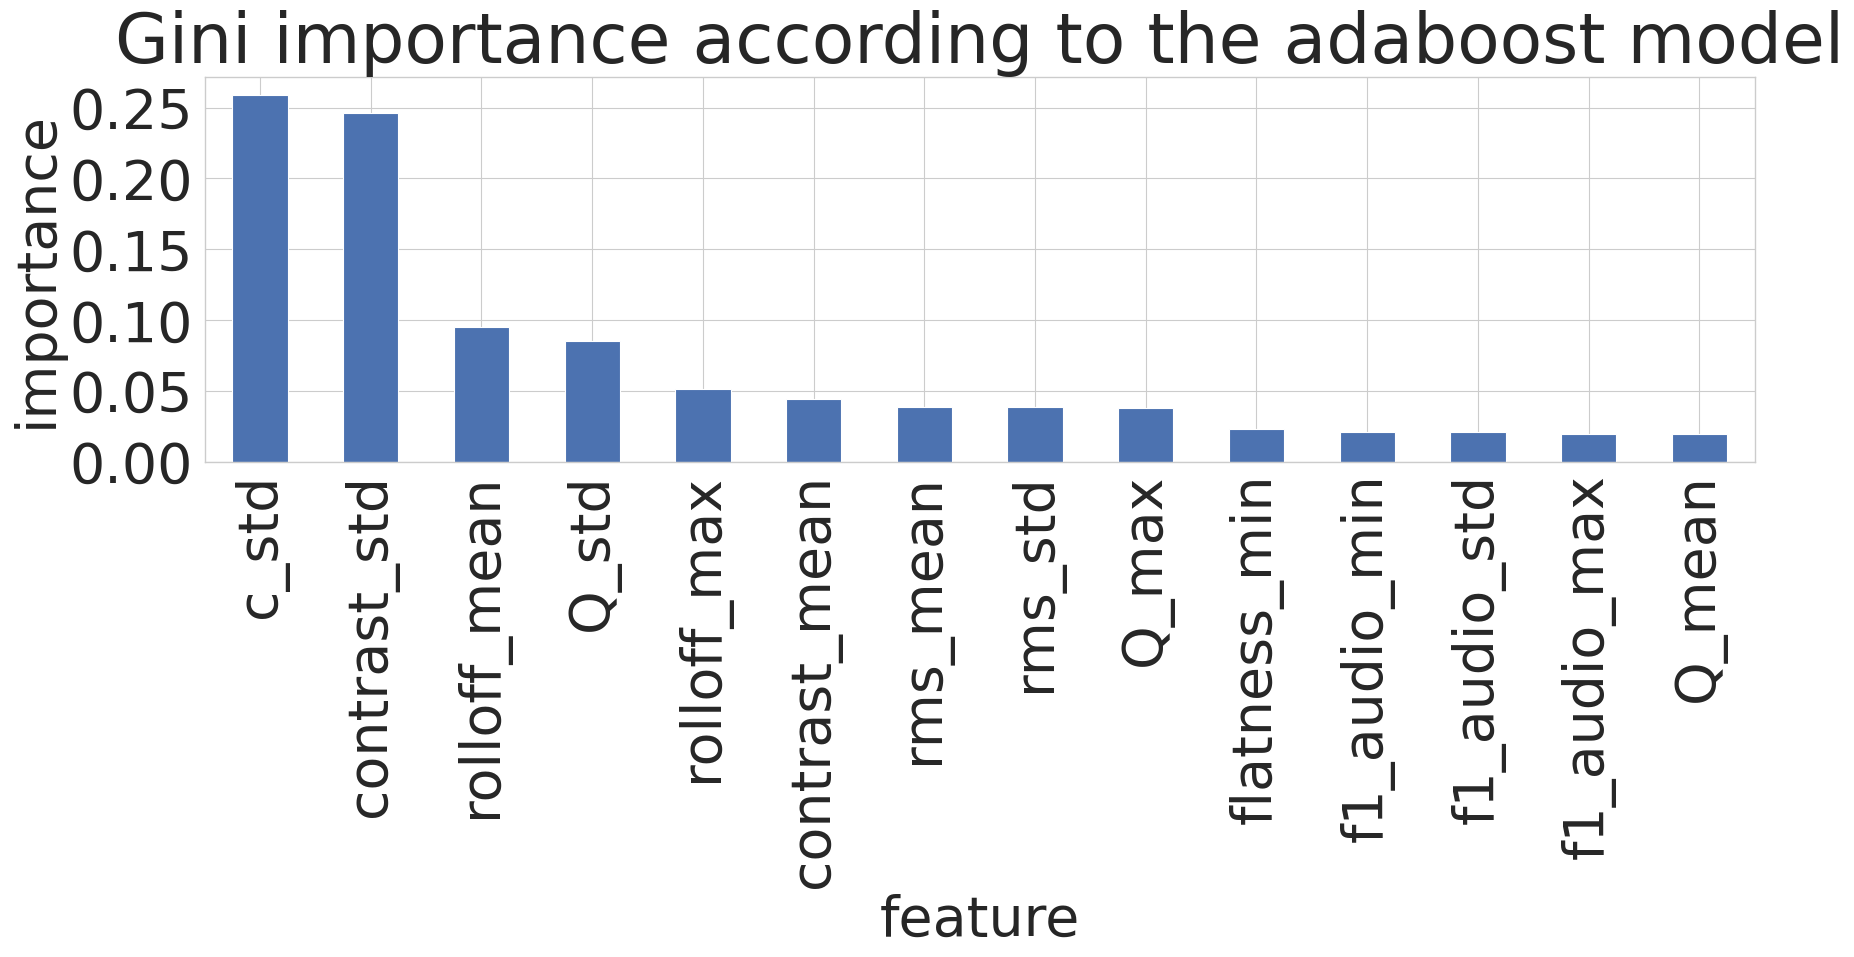

In [64]:
imp_adaboost = adaboost.feature_importances_

feat = X.columns

df_gini_adaboost = pd.DataFrame({'importance': imp_adaboost[imp_adaboost > 0], 'feature': feat[imp_adaboost > 0]})
df_gini_adaboost = df_gini_adaboost.sort_values(by='importance', ascending=False)
print(df_gini_adaboost)

df_gini_adaboost.plot.bar(x='feature', legend=False, figsize=(20, 5), fontsize=40)
plt.title("Gini importance according to the adaboost model", fontsize=50)
plt.ylabel("importance", fontsize=40)
plt.xlabel('feature', fontsize=40)
plt.show()
